# 07 — Model Experiments

## EduPredict — Student Exam Performance Prediction

This notebook compares multiple regression algorithms using the feature-engineered Student Performance dataset.

### Objectives
- Load the engineered dataset and feature-selection decision.
- Recreate a leakage-safe train/validation/test split.
- Build a common preprocessing pipeline.
- Compare several regression models on the **same validation split**.
- Use RMSE as the primary model-selection metric, with MAE and R² as supporting metrics.
- Keep the test set untouched until final evaluation in Notebook 08.
- Include PCA only if Notebook 06 selected PCA based on validation performance.
- Save experiment results for reproducibility and later MLflow integration.

> **Important:** This notebook does not use `Exam_Score` as an input feature. The test set is not used for model selection.


In [1]:
# 1. Imports and configuration

from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor
)

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

DATA_PATH = Path("../data/processed/student_performance_engineered.csv")
SELECTION_PATH = Path("../outputs/metrics/selected_features.json")
PCA_SUMMARY_PATH = Path("../outputs/metrics/pca_summary.json")

print("Configuration loaded.")
print("Dataset:", DATA_PATH)


Configuration loaded.
Dataset: ../data/processed/student_performance_engineered.csv


In [2]:
# 2. Load engineered dataset

df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

assert "Exam_Score" in df.columns, "Target column Exam_Score not found."

print("\nTarget summary:")
display(df["Exam_Score"].describe())


Dataset shape: (6606, 22)

Columns:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score', 'Study_Attendance_Interaction', 'Study_Sleep_Interaction']

Target summary:


count    6606.000000
mean       67.230548
std         3.868502
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       100.000000
Name: Exam_Score, dtype: float64

In [3]:
# 3. Load feature-selection decision

if SELECTION_PATH.exists():
    with open(SELECTION_PATH, "r") as f:
        selection_info = json.load(f)

    selected_features = selection_info.get("selected_features", [])
else:
    selected_features = []

candidate_features = [
    c for c in df.columns
    if c != "Exam_Score"
]

# Only use selected features if the saved file contains valid feature names.
selected_features = [
    c for c in selected_features
    if c in candidate_features
]

if selected_features:
    feature_columns = selected_features
    selection_source = "Notebook 05 selected features"
else:
    feature_columns = candidate_features
    selection_source = "All engineered candidate features"

print("Feature selection source:", selection_source)
print("Number of input features:", len(feature_columns))
print("\nFeatures:")
print(feature_columns)


Feature selection source: All engineered candidate features
Number of input features: 21

Features:
['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Study_Attendance_Interaction', 'Study_Sleep_Interaction']


In [4]:
# 4. Create leakage-safe train / validation / test split

from sklearn.model_selection import train_test_split

X = df[feature_columns].copy()
y = df["Exam_Score"].copy()

# First lock the final test set.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

# Validation set comes only from the training portion.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

print("\ny_train:", y_train.shape)
print("y_val  :", y_val.shape)
print("y_test :", y_test.shape)

print("\nThe test set remains untouched for final evaluation.")


X_train: (4227, 21)
X_val  : (1057, 21)
X_test : (1322, 21)

y_train: (4227,)
y_val  : (1057,)
y_test : (1322,)

The test set remains untouched for final evaluation.


In [5]:
# 5. Identify numerical and categorical columns

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "string"]
).columns.tolist()

print("Numerical features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)


Numerical features: 8
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity', 'Study_Attendance_Interaction', 'Study_Sleep_Interaction']

Categorical features: 13
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [6]:
# 6. Common preprocessing pipeline
#
# Numerical:
#   median imputation -> scaling
#
# Categorical:
#   most-frequent imputation -> one-hot encoding
#
# All preprocessing is fitted only on the training data.

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Preprocessor created.")


Preprocessor created.


In [7]:
# 7. Define candidate regression models

models = {
    "LinearRegression": LinearRegression(),

    "Ridge": Ridge(
        alpha=1.0
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "ExtraTrees": ExtraTreesRegressor(
        n_estimators=200,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=RANDOM_STATE
    ),

    "HistGradientBoosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_leaf_nodes=31,
        random_state=RANDOM_STATE
    )
}

print("Models to compare:")
for name in models:
    print("-", name)


Models to compare:
- LinearRegression
- Ridge
- RandomForest
- ExtraTrees
- GradientBoosting
- HistGradientBoosting


In [8]:
# 8. Train and evaluate models on the validation set

results = []
trained_models = {}

for name, estimator in models.items():

    print(f"Training {name}...")

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", estimator)
    ])

    pipeline.fit(X_train, y_train)

    val_pred = pipeline.predict(X_val)

    rmse = mean_squared_error(y_val, val_pred) ** 0.5
    mae = mean_absolute_error(y_val, val_pred)
    r2 = r2_score(y_val, val_pred)

    results.append({
        "model": name,
        "validation_rmse": rmse,
        "validation_mae": mae,
        "validation_r2": r2
    })

    trained_models[name] = pipeline

results_df = (
    pd.DataFrame(results)
    .sort_values("validation_rmse")
    .reset_index(drop=True)
)

display(results_df)


Training LinearRegression...
Training Ridge...
Training RandomForest...
Training ExtraTrees...
Training GradientBoosting...
Training HistGradientBoosting...


,model,validation_rmse,validation_mae,validation_r2
0,LinearRegression,1.882375,0.492524,0.751767
1,Ridge,1.882486,0.492781,0.751737
2,GradientBoosting,2.029278,0.801298,0.711510
3,HistGradientBoosting,2.030796,0.806588,0.711078
4,ExtraTrees,2.201395,1.054243,0.660497
5,RandomForest,2.297654,1.131135,0.630157


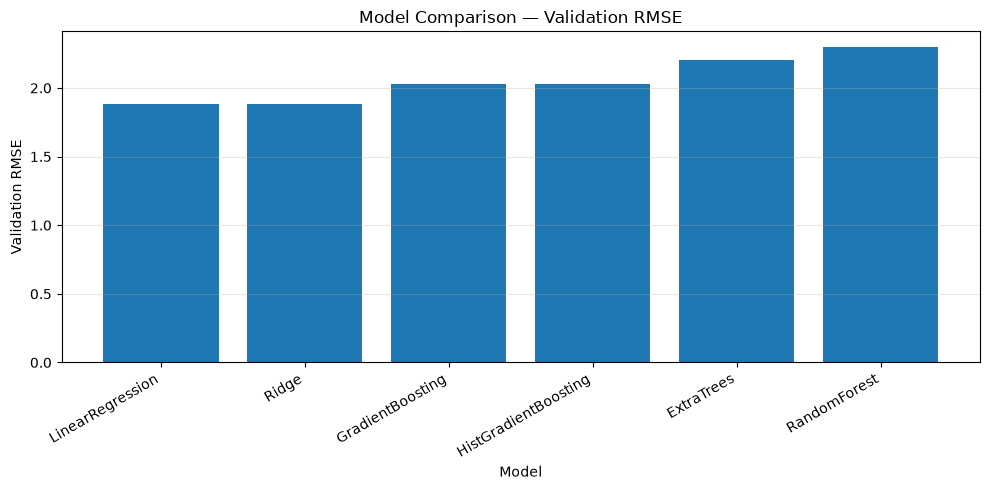

In [9]:
# 9. Visualize model comparison

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    results_df["model"],
    results_df["validation_rmse"]
)

plt.xlabel("Model")
plt.ylabel("Validation RMSE")
plt.title("Model Comparison — Validation RMSE")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [10]:
# 10. Compare models across all validation metrics

metric_table = results_df[
    [
        "model",
        "validation_rmse",
        "validation_mae",
        "validation_r2"
    ]
].copy()

metric_table["validation_rmse"] = metric_table["validation_rmse"].round(4)
metric_table["validation_mae"] = metric_table["validation_mae"].round(4)
metric_table["validation_r2"] = metric_table["validation_r2"].round(4)

display(metric_table)


,model,validation_rmse,validation_mae,validation_r2
0,LinearRegression,1.8824,0.4925,0.7518
1,Ridge,1.8825,0.4928,0.7517
2,GradientBoosting,2.0293,0.8013,0.7115
3,HistGradientBoosting,2.0308,0.8066,0.7111
4,ExtraTrees,2.2014,1.0542,0.6605
5,RandomForest,2.2977,1.1311,0.6302


In [11]:
# 11. Identify the validation champion

champion_name = results_df.iloc[0]["model"]
champion_rmse = results_df.iloc[0]["validation_rmse"]

champion_model = trained_models[champion_name]

print("Validation champion:", champion_name)
print(f"Validation RMSE: {champion_rmse:.4f}")
print()
print("This is a validation result only.")
print("The test set has NOT been used to select the champion.")


Validation champion: LinearRegression
Validation RMSE: 1.8824

This is a validation result only.
The test set has NOT been used to select the champion.


In [12]:
# 12. Check whether PCA was selected in Notebook 06

pca_selected = False
selected_components = None

if PCA_SUMMARY_PATH.exists():
    with open(PCA_SUMMARY_PATH, "r") as f:
        pca_summary = json.load(f)

    pca_selected = bool(pca_summary.get("pca_selected", False))
    selected_components = pca_summary.get("selected_components")

print("PCA selected by Notebook 06:", pca_selected)
print("Selected components:", selected_components)


PCA selected by Notebook 06: False
Selected components: None


In [13]:
# 13. Optional PCA comparison using the validation champion model family
#
# PCA is treated as an experiment, not automatically as an improvement.
# If Notebook 06 selected PCA, compare the same champion estimator
# with the selected number of components.

if pca_selected and selected_components is not None:

    from sklearn.decomposition import PCA

    pca_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("pca", PCA(
            n_components=int(selected_components),
            random_state=RANDOM_STATE
        )),
        ("model", models[champion_name])
    ])

    pca_pipeline.fit(X_train, y_train)

    pca_val_pred = pca_pipeline.predict(X_val)

    pca_rmse = mean_squared_error(y_val, pca_val_pred) ** 0.5
    pca_mae = mean_absolute_error(y_val, pca_val_pred)
    pca_r2 = r2_score(y_val, pca_val_pred)

    print("PCA + champion model")
    print("--------------------")
    print(f"Model: {champion_name}")
    print(f"Components: {selected_components}")
    print(f"RMSE: {pca_rmse:.4f}")
    print(f"MAE : {pca_mae:.4f}")
    print(f"R²  : {pca_r2:.4f}")

else:
    pca_pipeline = None
    pca_rmse = None
    pca_mae = None
    pca_r2 = None

    print("PCA was not selected in Notebook 06.")
    print("Continuing with the non-PCA model experiments.")


PCA was not selected in Notebook 06.
Continuing with the non-PCA model experiments.


In [14]:
# 14. Save model experiment results

metrics_dir = Path("../outputs/metrics")
metrics_dir.mkdir(parents=True, exist_ok=True)

results_df.to_csv(
    metrics_dir / "model_experiment_results.csv",
    index=False
)

experiment_summary = {
    "champion_model": champion_name,
    "champion_validation_rmse": float(champion_rmse),
    "champion_validation_mae": float(
        results_df.iloc[0]["validation_mae"]
    ),
    "champion_validation_r2": float(
        results_df.iloc[0]["validation_r2"]
    ),
    "pca_selected_in_notebook_06": pca_selected,
    "pca_components": (
        int(selected_components)
        if selected_components is not None
        else None
    ),
    "pca_champion_rmse": (
        float(pca_rmse)
        if pca_rmse is not None
        else None
    )
}

with open(
    metrics_dir / "model_experiment_summary.json",
    "w"
) as f:
    json.dump(experiment_summary, f, indent=4)

print("Saved:")
print("- outputs/metrics/model_experiment_results.csv")
print("- outputs/metrics/model_experiment_summary.json")


Saved:
- outputs/metrics/model_experiment_results.csv
- outputs/metrics/model_experiment_summary.json


## Why these models?

| Model | Why included |
|---|---|
| Linear Regression | Simple interpretable baseline for a regression problem |
| Ridge | Tests whether regularization improves the linear baseline, especially after one-hot encoding |
| Random Forest | Captures nonlinear relationships and feature interactions |
| Extra Trees | Tests a more randomized tree ensemble against Random Forest |
| Gradient Boosting | Strong sequential boosting baseline for nonlinear tabular data |
| HistGradientBoosting | Efficient gradient boosting implementation for larger tabular datasets |

### Selection rule

The validation **RMSE** is the primary selection metric because the project predicts a continuous exam score and RMSE penalizes larger prediction errors more strongly.

MAE is retained because it is directly interpretable as average absolute score error.

R² is reported as a complementary measure of explained variance.

The final test-set result is intentionally deferred to `08_model_evaluation.ipynb`.


## Notebook 07 completion checklist

Before moving to Notebook 08, verify:

- [ ] Dataset loaded successfully.
- [ ] Feature-selection decision loaded.
- [ ] Train/validation/test split created.
- [ ] Test set remained untouched.
- [ ] Common preprocessing pipeline completed.
- [ ] All candidate models trained.
- [ ] Validation RMSE/MAE/R² generated.
- [ ] Validation champion identified.
- [ ] PCA decision checked.
- [ ] Results saved to `outputs/metrics/`.
- [ ] No metrics were manually entered or fabricated.

**Next notebook:** `08_model_evaluation.ipynb`
